# Testing the functional API in correct order

In [ ]:
import importlib
import SpatialAPI
import scanpy as sc
import pandas as pd
import spatialdata as sd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Read data

In [ ]:
sdata_path = "/path/to/sdata"
sdata = SpatialAPI.read_data(sdata_path)

adata = sdata.tables["table"].copy()

# Metrics (1)

In [4]:
# Get metrics (does the same thing as the cell above, only it returns both the values instead of 1)
perc_transcripts, s_pos = SpatialAPI.metrics(sdata)

print(f"The percentage transcripts allocated: {perc_transcripts}%")
print(f"The percentage staining positive pixels: {s_pos}%")

The percentage transcripts allocated: 91.13%
The percentage staining positive pixels: 81.75%


# QC (2)

In [4]:
# percentage of control probes and control codewords
(control_probe_percentage, control_codeword_percentage) = SpatialAPI.control_probes_codew(adata)

The column 'n_genes_by_counts' is not present in the data. Computing this column...
Column 'n_genes_by_counts' is computed. Generating visualizations...


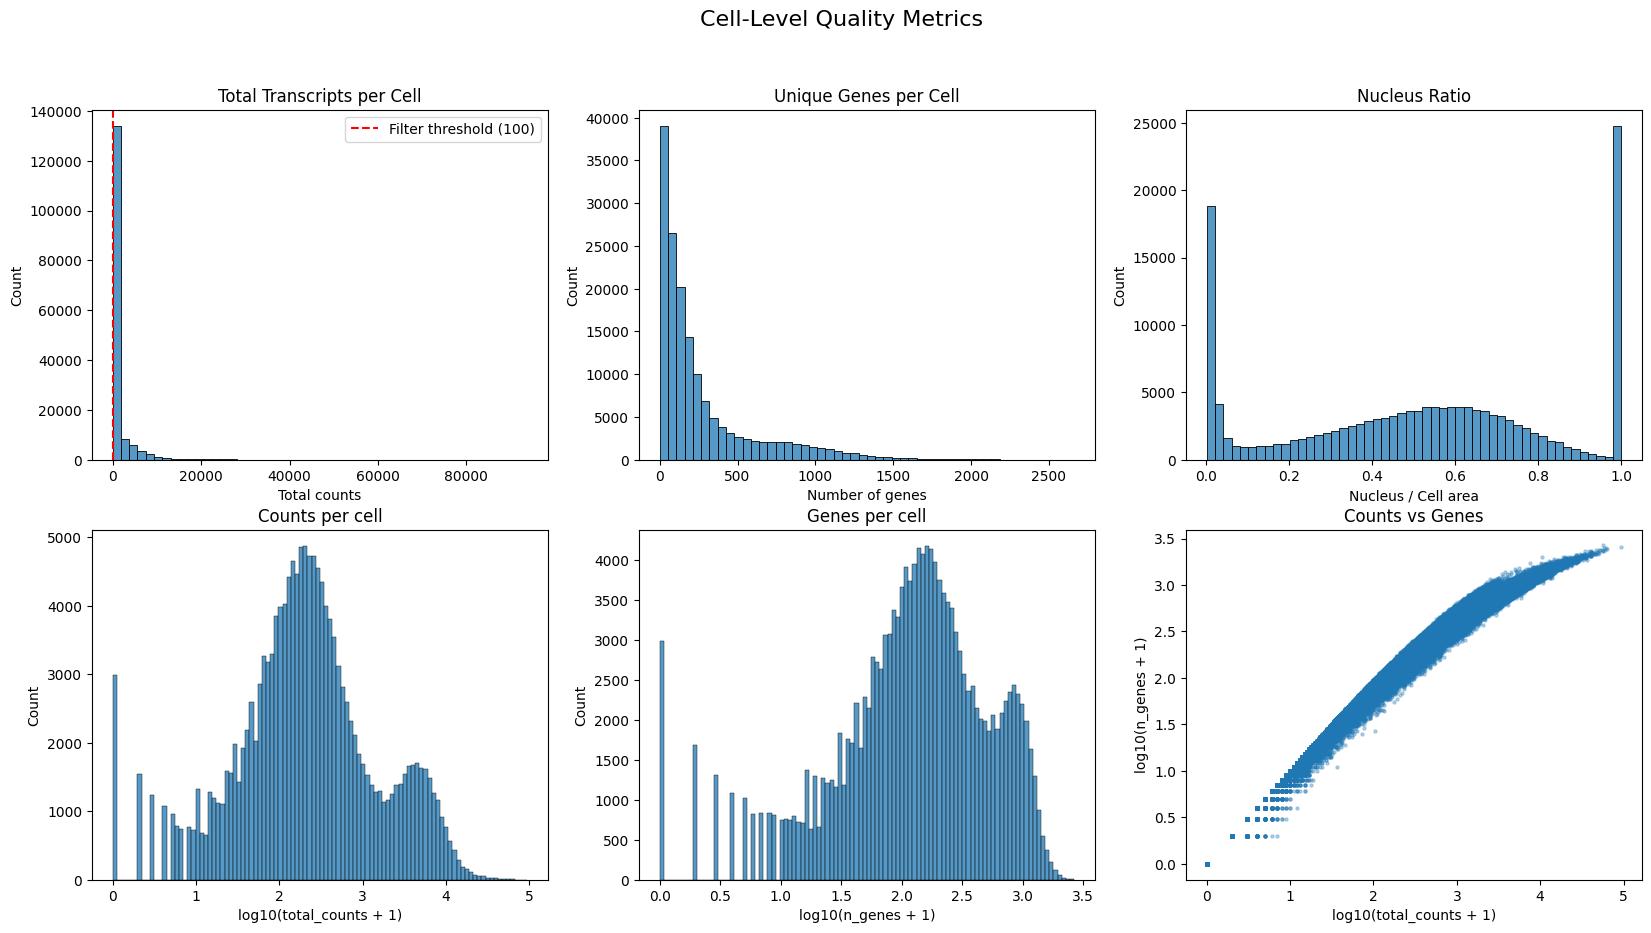

The distribution plots are saved in the current running directory: /exports/archive/hg-groep-spitali/Emma/xenium-resegmentation/SpatialAPI/cell_statistics.png


In [5]:
# standard QC diagnostic plots
fig = SpatialAPI.plot_qc_metrics(adata, save=True)

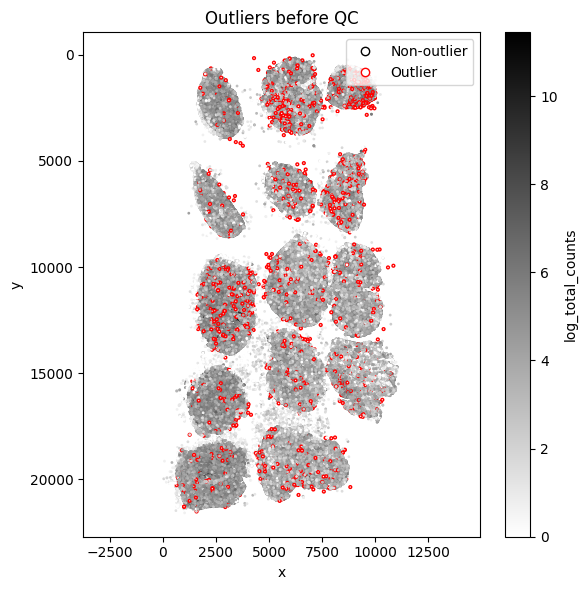

In [6]:
adata.obs['low_counts_outlier'] = SpatialAPI.is_outlier(adata.obs['total_counts'], direction='lower')
adata = SpatialAPI.detect_outlier(adata)
fig = SpatialAPI.plot_outliers(adata,"region", metric = "log_total_counts", outliers="log_total_counts_outliers", title="Outliers before QC", legend=True, ring_overlay=False)

In [7]:
# recommended threshold based on QC values and percentiles
thr = SpatialAPI.recommend_threshold(adata)
print(thr)

{'min_genes': 0, 'max_genes': 1389, 'min_counts': 0, 'max_counts': 11561}


In [8]:
thr = {
    "min_genes": 10,
    "max_genes": 600,
    "min_counts": 30,
    "max_counts": 1000
}

In [9]:
# perform quality control and normalization of the data
adata_filtered = SpatialAPI.perform_quality_control(adata, thr)

Cells before filtering: 156628
Cells after filtering: 103479


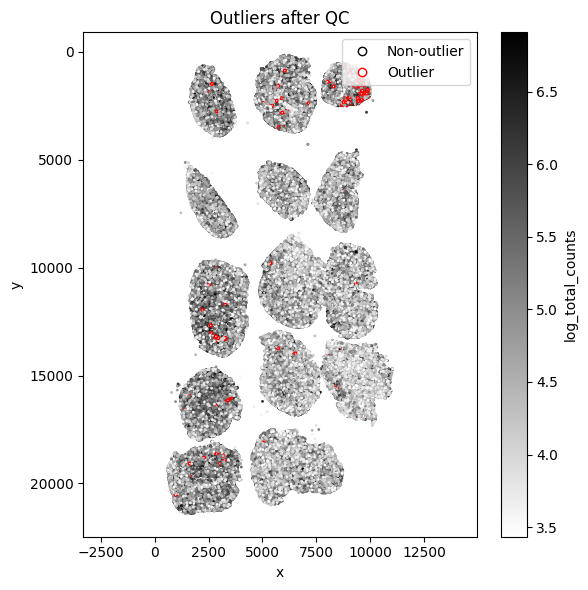

In [10]:
# adata_filtered.obs['low_counts_outlier'] = pipeline.is_outlier(adata_filtered.obs['total_counts'], direction='lower')
# adata_filtered = pipeline.detect_outlier(adata_filtered)
fig = SpatialAPI.plot_outliers(adata_filtered,"region", metric = "log_total_counts", outliers="log_total_counts_outliers", title="Outliers after QC", legend=True, ring_overlay=False)

In [11]:
# keep raw counts as a copy
adata_filtered.layers["raw_counts"] = adata_filtered.X.copy()

sc.pp.normalize_total(adata_filtered, target_sum=1e4)
sc.pp.log1p(adata_filtered)

# Compute ARI (Leiden Resolution)

In [12]:
adata, best_res, table = SpatialAPI.compute_leiden_resolution(adata, fast_mode=True)

print("Best resolution:", best_res)
print(table)

Best resolution: 1.2
   resolution  n_clusters  stability  modularity     score
0         0.2          66        1.0    0.726931  0.918079
1         0.4          73        1.0    0.769840  0.930952
2         0.6          79        1.0    0.815470  0.944641
3         0.8          83        1.0    0.814116  0.944235
4         1.0          86        1.0    0.823831  0.947149
5         1.2          91        1.0    0.829435  0.948831
6         1.4          95        1.0    0.825647  0.947694
7         1.6         103        1.0    0.826121  0.947836
8         1.8         108        1.0    0.823129  0.946939
9         2.0         116        1.0    0.826668  0.948000


# Cluster (3)

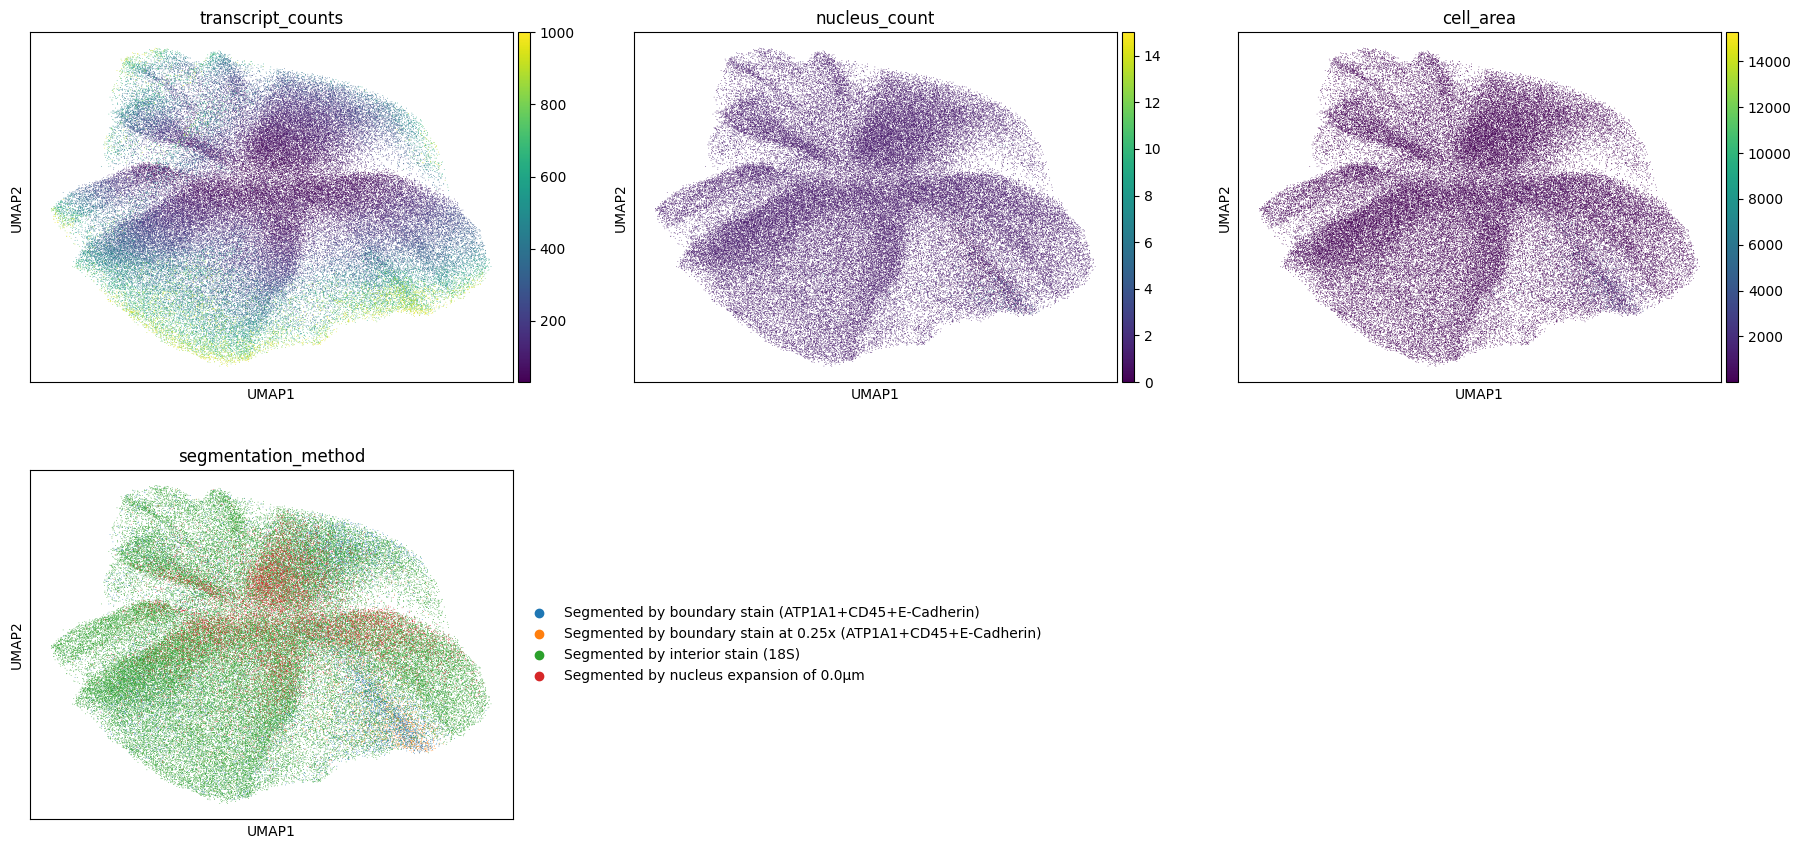

In [13]:
adata_cluster = SpatialAPI.cluster(adata_filtered, n_comps=50, n_neighbors=15, n_pcs=30)

# Ranking genes (4)

Leiden clustering has not been performed yet. Adding 'Leiden' column...


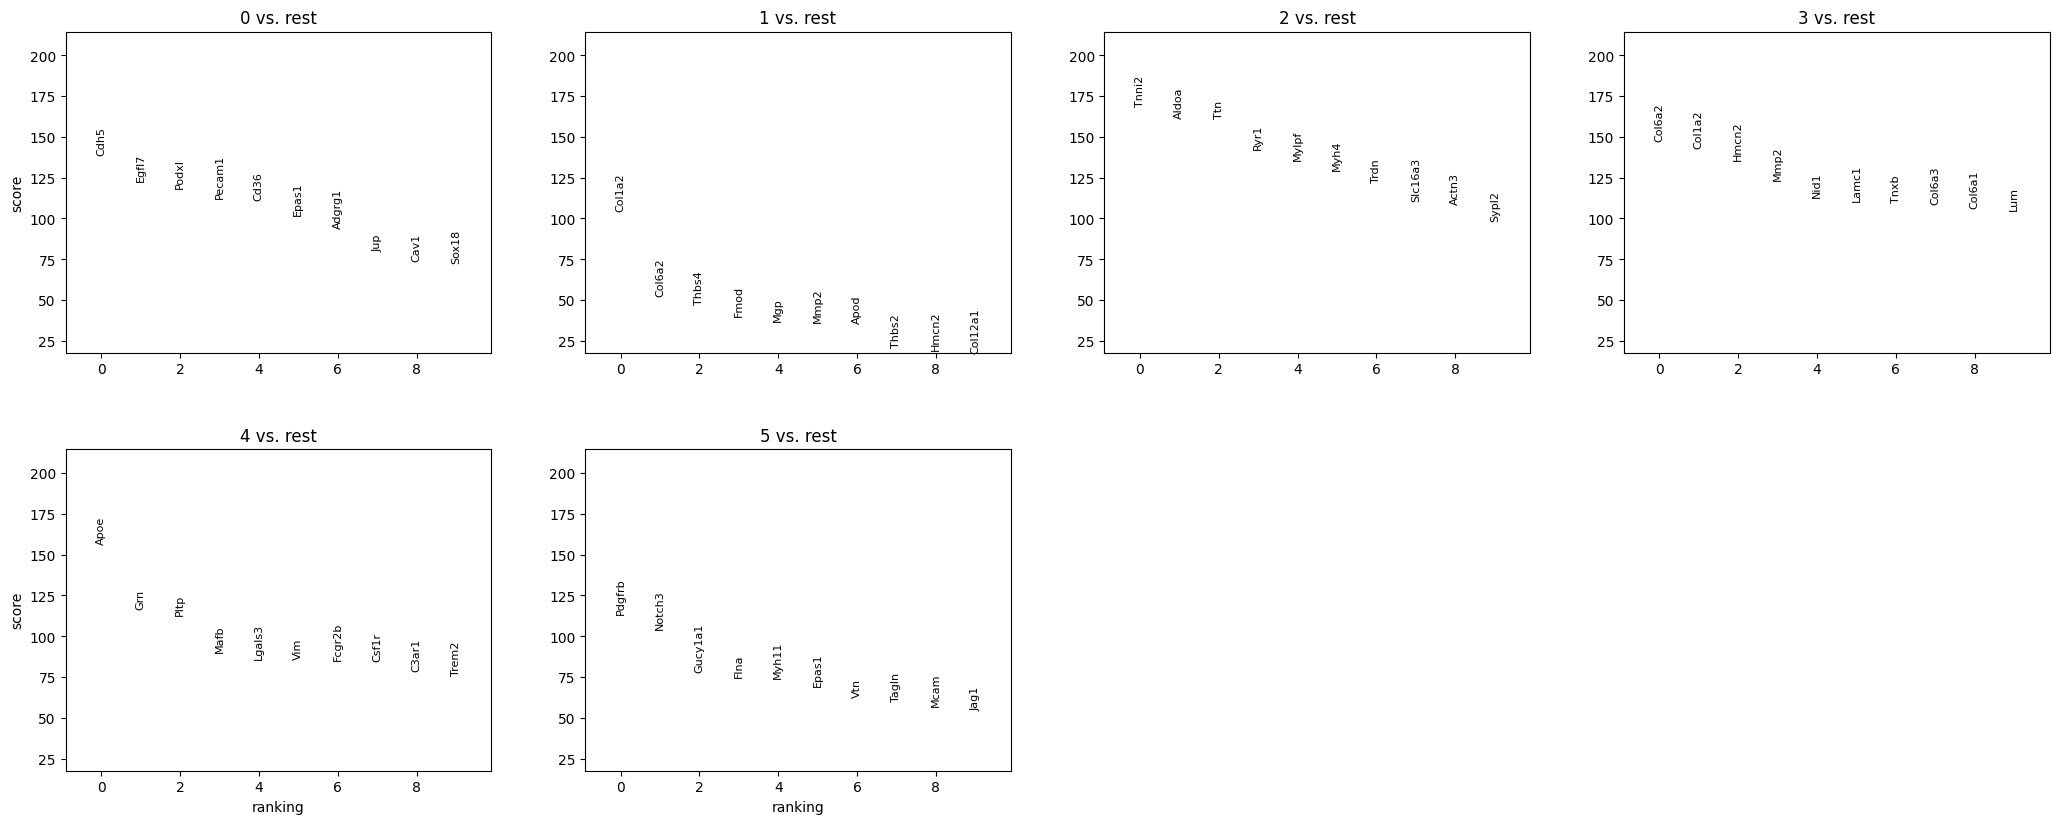

In [ ]:
# show the top 10 genes per cluster (Leiden)
adata_ranked = SpatialAPI.rank_genes_group(adata_cluster, res=0.3)

# Multimodal segmentation (5)

INFO     Rasterizing image for faster rendering.                                                                   
If you want to zoom in on specific slices, run multimodal_segmentation_slice.


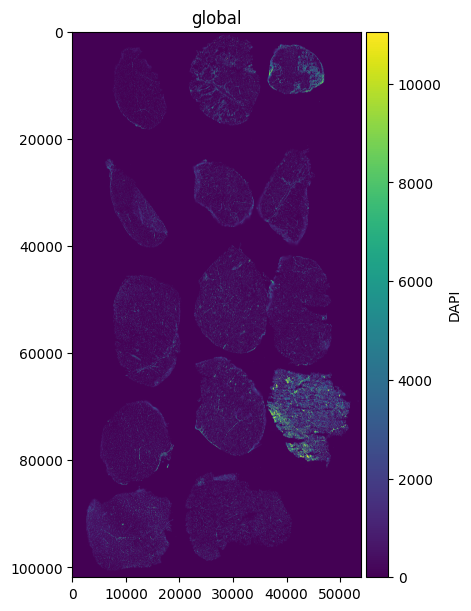

In [ ]:
channel_names = sd.models.get_channel_names(sdata["morphology_focus"])

SpatialAPI.multimodal_segmentation(sdata, channelnames=["DAPI"])

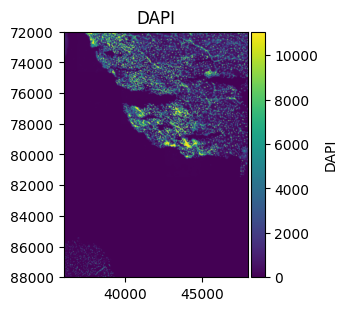

In [16]:
# Get the slice of the multimodal segmentation
SpatialAPI.multimodal_segmentation_slice(sdata, channelnames=['DAPI'])

# Visuals (6)

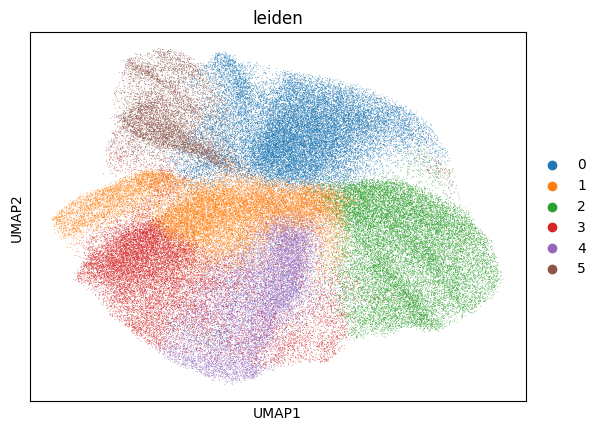

AnnData object with n_obs × n_vars = 103479 × 5056
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'n_genes_by_counts', 'low_counts_outlier', 'log_total_counts', 'log_total_counts_z', 'log_total_counts_outliers', 'density', 'leiden'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'spatialdata_attrs', 'log1p', 'pca', 'neighbors', 'umap', 'segmentation_method_colors', 'leiden', 'rank_genes_groups', 'leiden_colors'
    obsm: 'spatial', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'raw_counts'
    obsp: 'distances', 'connectivities'

In [19]:
SpatialAPI.cluster(adata_ranked, colors=["leiden"])

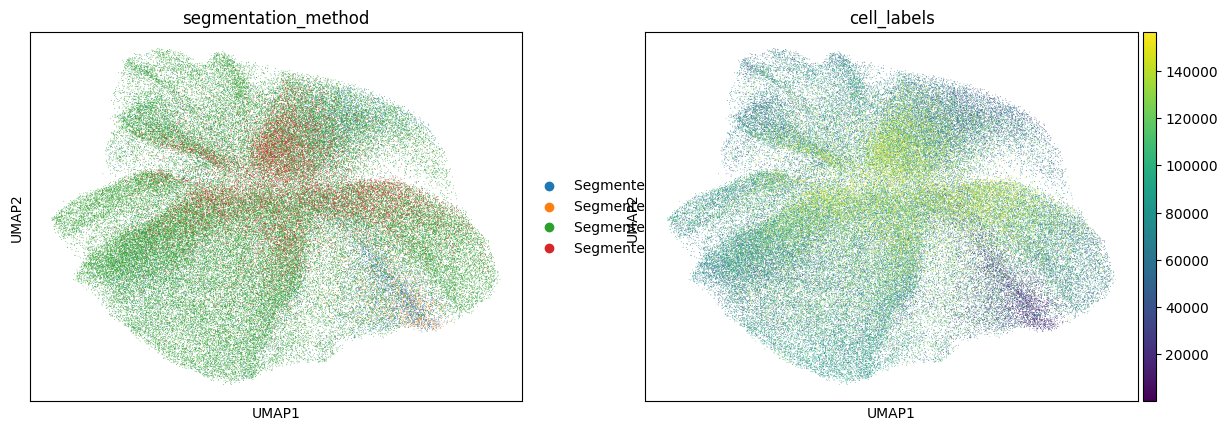

AnnData object with n_obs × n_vars = 103479 × 5056
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'n_genes_by_counts', 'low_counts_outlier', 'log_total_counts', 'log_total_counts_z', 'log_total_counts_outliers', 'density', 'leiden'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'spatialdata_attrs', 'log1p', 'pca', 'neighbors', 'umap', 'segmentation_method_colors', 'leiden', 'rank_genes_groups', 'leiden_colors'
    obsm: 'spatial', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'raw_counts'
    obsp: 'distances', 'connectivities'

In [20]:
SpatialAPI.cluster(adata_ranked, colors=['segmentation_method', 'cell_labels'])

# Assigning treatments (7)

Loaded 156,628 rows.
Grid: 559 x 1081 px  (20 µm/px)
Seeds after erosion: 13
Components after watershed: 13

✓ 13 sample(s)  |  3,134 unassigned cells


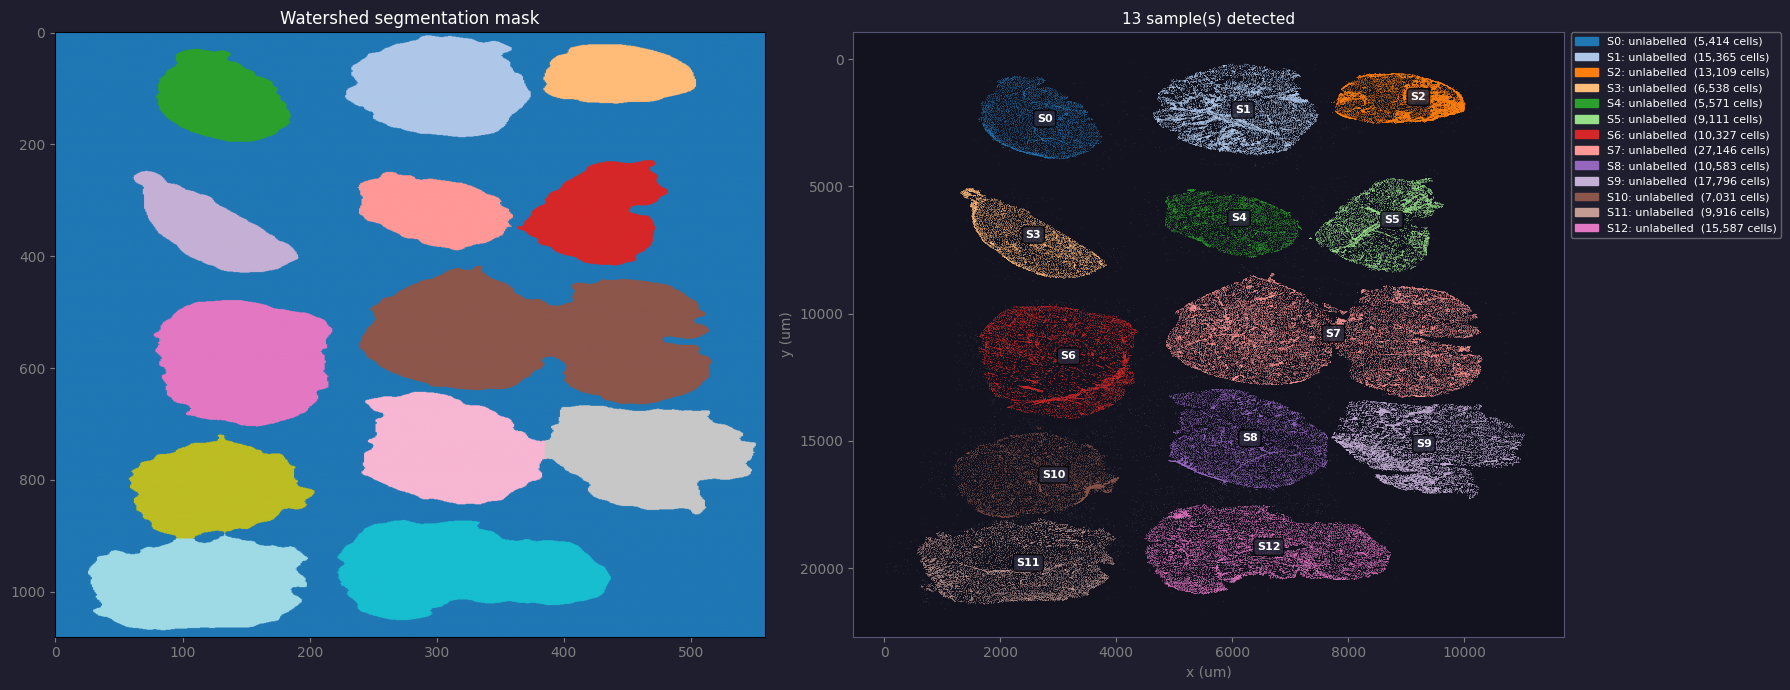

In [ ]:
path_xenium = "/path/to/xenium/outs/"
output_dir = "output_dir"

df = SpatialAPI.run_watershed(path_xenium, output_dir)

In [18]:
# perform manual split
df_split_base = df.copy()
session = SpatialAPI.SplitSession(df_split_base)
session.show()

Output()

In [33]:
# get results from splitting
df_results, ids = session.result()

# pass to the labelling session (LabelSession)
label_session = SpatialAPI.LabelSession(df_results, ids, adata=adata_ranked, output_dir=output_dir)
label_session.show()

# perform label assignment
conditions = label_session.result()

Output()

In [ ]:
# write results of assignment to h5ad file, so it can be reused whenever you want.
adata_ranked.write("adata_labels_assigned.h5ad")

# Annotations (8)

In [34]:
# Do NOT use adata object with highly variable genes, just the 'original'.
df = sc.get.rank_genes_groups_df(
    adata_ranked,
    group=None,
    pval_cutoff=0.05
)

top_markers = (
    df
    .sort_values(["group", "scores"], ascending=[True, False])
    .groupby("group")
    .head(10)
)

marker_summary = (
    top_markers
    .groupby("group")["names"]
    .apply(list)
)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", None)
marker_summary.to_csv("cluster_marker_summary.csv")
marker_summary

group
0      [Cdh5, Egfl7, Podxl, Pecam1, Cd36, Epas1, Adgrg1, Jup, Cav1, Sox18]
1    [Col1a2, Col6a2, Thbs4, Fmod, Mgp, Mmp2, Apod, Thbs2, Hmcn2, Col12a1]
2      [Tnni2, Aldoa, Ttn, Ryr1, Mylpf, Myh4, Trdn, Slc16a3, Actn3, Sypl2]
3    [Col6a2, Col1a2, Hmcn2, Mmp2, Nid1, Lamc1, Tnxb, Col6a3, Col6a1, Lum]
4        [Apoe, Grn, Pltp, Mafb, Lgals3, Vim, Fcgr2b, Csf1r, C3ar1, Trem2]
5    [Pdgfrb, Notch3, Gucy1a1, Flna, Myh11, Epas1, Vtn, Tagln, Mcam, Jag1]
Name: names, dtype: object

In [ ]:
cluster_to_celltype = {
    "0": "Endothelial cells",
    "1": "FAPs/Fibroblasts",
    "2": "Fast skeletal muscle fibers",
    "3": "Fibroblasts",
    "4": "Macrophages",
    "5": "Pericytes",
}

adata_ranked.obs["cell_type"] = adata_ranked.obs["leiden"].map(cluster_to_celltype)

# Analysis (9)

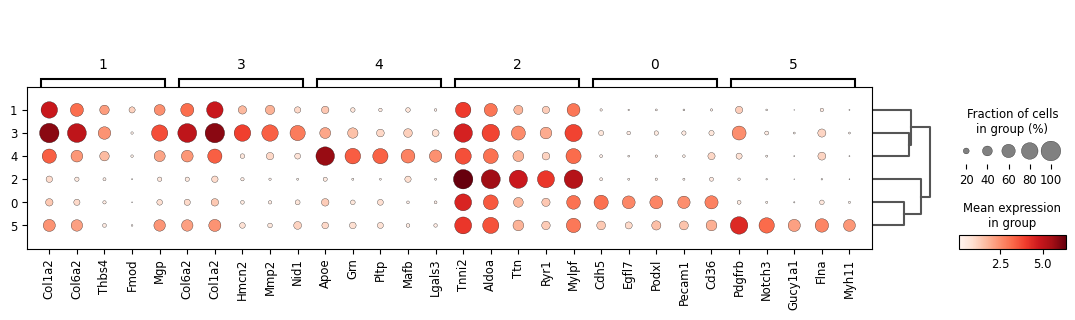

In [36]:
SpatialAPI.dotplot(adata_ranked)

In [37]:
adata_test = adata_ranked.copy()

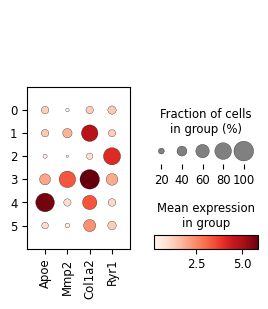

In [38]:
SpatialAPI.dotplot(adata_test, markers=["Apoe", "Mmp2", "Col1a2", 'Ryr1'])

  0%|          | 0/1000 [00:00<?, ?/s]

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

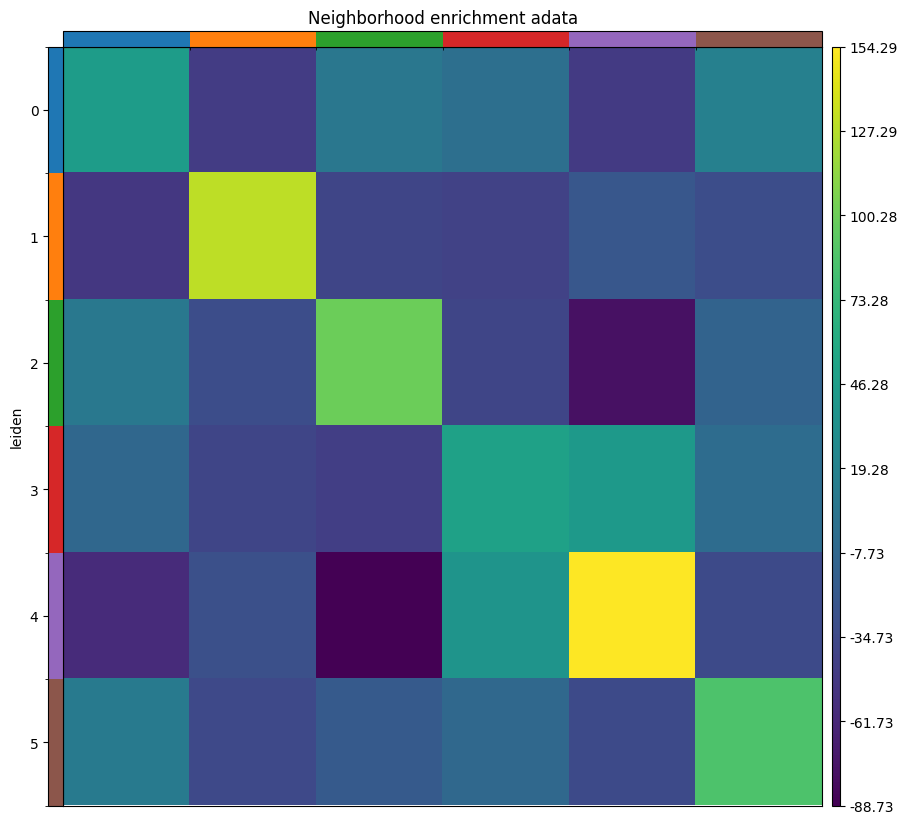

In [40]:
SpatialAPI.nhood_enrichment(adata_test) 

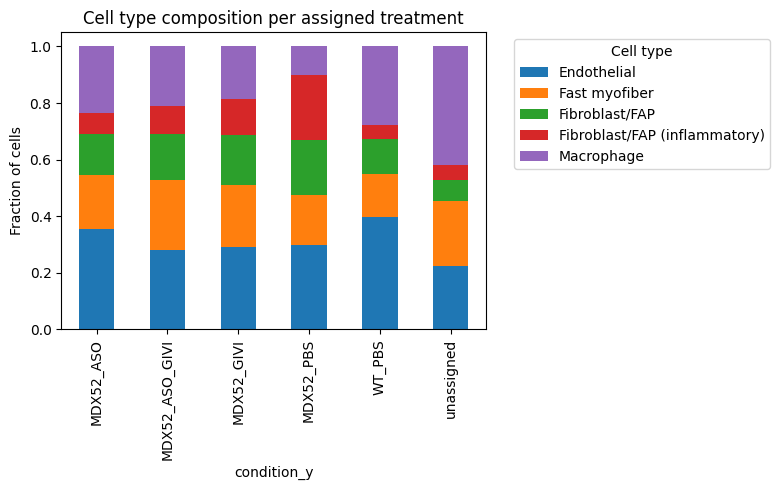

In [ ]:
SpatialAPI.celltype_composition(adata_test, condition="condition")

In [ ]:
uni = adata_test.obs["condition"].unique().tolist()[:2]

# Always put in the cell types and the conditions you want to perform the analysis on (list-format)
SpatialAPI.pseudobulk(adata_test, celltype="Endothelial", sample_col="sample_id", cond=uni, treatment_col="condition")

Processing Fast myofiber...
Processing Fibroblast/FAP (inflammatory)...
Processing Macrophage...
Processing Fibroblast/FAP...
Processing Endothelial...


Fitting size factors...
... done in 0.00 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 0.79 seconds.

Fitting dispersion trend curve...
... done in 0.10 seconds.

Fitting MAP dispersions...
... done in 1.40 seconds.

Fitting LFCs...
... done in 0.87 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.42 seconds.



Log2 fold change & Wald test p-value: condition_y MDX52_ASO_GIVI vs MDX52_PBS
                                 baseMean  log2FoldChange     lfcSE      stat  \
A1cf                             0.047541        0.323519  5.399040  0.059922   
A2m                              0.421487        0.815522  1.681406  0.485024   
Aatf                            70.093042        0.334380  0.247524  1.350897   
Abca1                          287.622350        0.013431  0.625484  0.021473   
Abca13                           0.000000             NaN       NaN       NaN   
Abca3                          132.141071        0.091468  0.299155  0.305755   
Abca4                            3.924697       -0.199273  0.785227 -0.253777   
Abca7                          105.197305        0.206158  0.215006  0.958850   
Abca8a                         114.785928        0.539377  0.383181  1.407629   
Abca8b                          44.292216        0.599344  0.296541  2.021116   
Abcb1a                         

# Computing Moran's I

In [58]:
df_moran = SpatialAPI.morans_score(adata)

  0%|          | 0/100 [00:00<?, ?/s]

In [ ]:
print(df_moran)

               I  pval_norm  var_norm  pval_z_sim  pval_sim   var_sim  \
Apoe    0.443632        0.0  0.000002         0.0  0.009901  0.000003   
Grn     0.437360        0.0  0.000002         0.0  0.009901  0.000004   
Vim     0.433618        0.0  0.000002         0.0  0.009901  0.000004   
Gpnmb   0.389567        0.0  0.000002         0.0  0.009901  0.000003   
Bgn     0.371405        0.0  0.000002         0.0  0.009901  0.000004   
Pltp    0.371166        0.0  0.000002         0.0  0.009901  0.000003   
Trem2   0.370586        0.0  0.000002         0.0  0.009901  0.000003   
Bglap2  0.361895        0.0  0.000002         0.0  0.009901  0.000003   
Ibsp    0.339152        0.0  0.000002         0.0  0.009901  0.000007   
Mgp     0.334946        0.0  0.000002         0.0  0.009901  0.000003   

        pval_norm_fdr_bh  pval_z_sim_fdr_bh  pval_sim_fdr_bh  
Apoe                 0.0                0.0          0.01184  
Grn                  0.0                0.0          0.01184  
Vim    

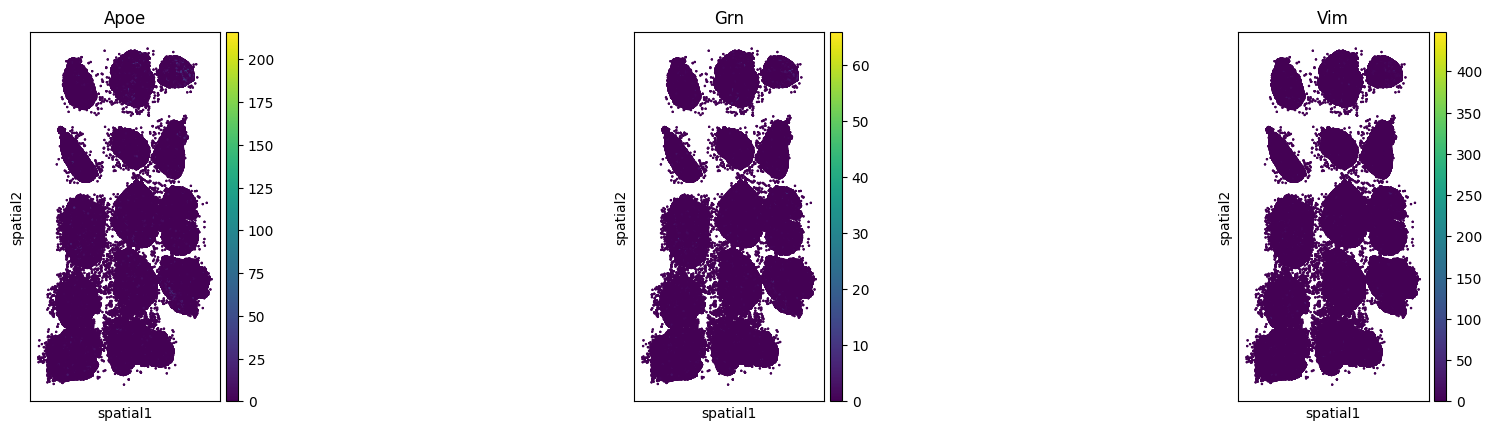

In [61]:
# Plot highst Moran's I score
# Dit zijn de markers met een Moran's I score boven de 0.4
colors = ["Apoe", "Grn", "Vim"] # list with highest morans I genes
SpatialAPI.plot_image(adata, colors)